/tmp/ipykernel_5097/3333042808.py:50: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipykernel_5097/3333042808.py:53: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root  = sqrtm(inner)
/tmp/ipykernel_5097/3333042808.py:50: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipykernel_5097/3333042808.py:53: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root  = sqrtm(inner)
/tmp/ipykernel_5097/3333042808.py:50: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipykernel_5097/3333042808.py:53: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root  = sqrtm(in

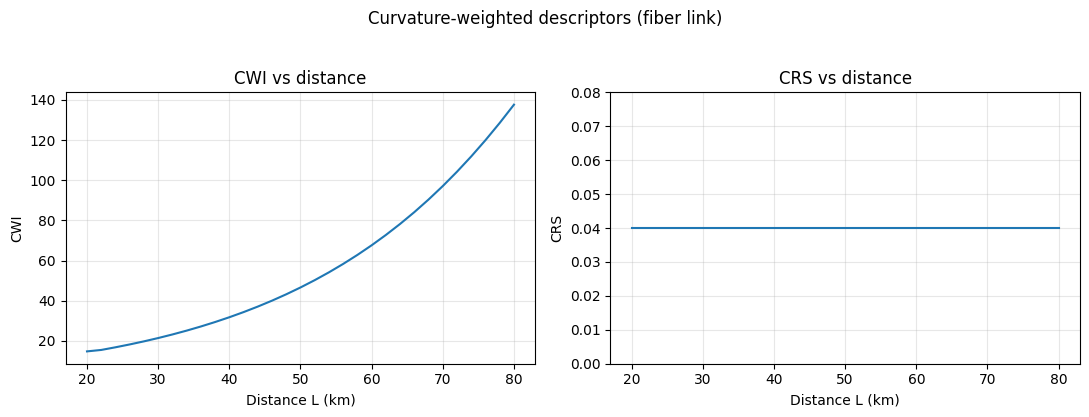

DONE. Saved in ./results:
 - figR1_curves_vs_L.jpg
 - figR2_local_fragility.jpg
 - figR3_QFF_vs_L.jpg
 - figR4_CWI_CRS_vs_L.jpg
 - tableR1_summary.csv


In [1]:
# ============================================
# Case study: Fiber link (dephasing conditioned on detections)
# p_phi(L) = 1 - exp(-L / L_phi)
# Outputs in ./results:
#   - figR1_curves_vs_L.jpg
#   - figR2_local_fragility.jpg
#   - figR3_QFF_vs_L.jpg
#   - figR4_CWI_CRS_vs_L.jpg
#   - tableR1_summary.csv
# ============================================

import os, shutil, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# -----------------------------
# Output folder
# -----------------------------
RESULTS_DIR = "./results"
if os.path.exists(RESULTS_DIR):
    shutil.rmtree(RESULTS_DIR)
os.makedirs(RESULTS_DIR, exist_ok=True)

# -----------------------------
# Linear algebra (Pauli)
# -----------------------------
I2 = np.eye(2, dtype=np.complex128)
X  = np.array([[0, 1],[1, 0]], dtype=np.complex128)
Y  = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
Z  = np.array([[1, 0],[0, -1]], dtype=np.complex128)

# -----------------------------
# States & geometry utilities
# -----------------------------
def pure_to_rho(psi):
    psi = np.asarray(psi, dtype=np.complex128).reshape(2,1)
    psi = psi / np.linalg.norm(psi)
    return psi @ psi.conj().T

def haar_random_pure_qubit(n: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    states = []
    for _ in range(n):
        z = rng.normal(size=2) + 1j * rng.normal(size=2)
        psi = z / np.linalg.norm(z)
        states.append(pure_to_rho(psi))
    return states

def fidelity(rho, sigma):
    sr = sqrtm(rho)
    inner = sr @ sigma @ sr
    inner = (inner + inner.conj().T) / 2.0  # numeric sym
    root  = sqrtm(inner)
    val   = np.real(np.trace(root))**2
    return float(np.clip(val, 0.0, 1.0))

def bures_distance(rho, sigma):
    F = fidelity(rho, sigma)
    return float(np.sqrt(max(0.0, 2.0*(1.0 - np.sqrt(F)))))

# -----------------------------
# Channels (Kraus)
# -----------------------------
def apply_kraus(rho, Ks):
    out = np.zeros((2,2), dtype=np.complex128)
    for K in Ks:
        out += K @ rho @ K.conj().T
    out = (out + out.conj().T) / 2.0
    tr = np.real(np.trace(out))
    return out / tr if tr != 0 else I2/2

def dephasing_kraus(p):
    p = float(np.clip(p, 0.0, 1.0))
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

# -----------------------------
# Trajectories & metrics
# -----------------------------
def trajectory(rho0, Ks, depth):
    traj = [rho0]
    rho = rho0
    for _ in range(depth):
        rho = apply_kraus(rho, Ks)
        traj.append(rho)
    return traj

def trajectory_length_bures(traj):
    return sum(bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

def gdi(traj):
    LB = trajectory_length_bures(traj)
    DB = bures_distance(traj[0], traj[-1])
    return float(LB / max(DB, 1e-12))

def gac_mean(traj):
    T = traj[-1]; vals=[]
    for i in range(len(traj)-1):
        A, B = traj[i], traj[i+1]
        dAB = bures_distance(A,B)
        dAT = bures_distance(A,T)
        dBT = bures_distance(B,T)
        denom = 2.0 * dAB * max(dAT, 1e-12)
        if denom <= 1e-12:
            continue
        cos_th = (dAB**2 + dAT**2 - dBT**2) / denom
        vals.append(np.clip(cos_th, -1.0, 1.0))
    return float(np.mean(vals)) if vals else 1.0

def bures_speeds_and_accel(traj):
    v = [bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1)]
    a = [abs(v[i+1] - 2*v[i] + v[i-1]) for i in range(1, len(v)-1)] if len(v) > 2 else []
    return v, a

# QFF: perturb derivative w.r.t. parameter (here distance L)
def qff_numeric(channel_param_fn, L, dL, depth, states, curvature_weight=False):
    # compute metric derivative of final state distance wrt L using central diff on fidelity-based quantity
    Lm, Lp = L - dL, L + dL
    vals = []
    for rho0 in states:
        p0 = channel_param_fn(L);   Ks0 = dephasing_kraus(p0)
        pm = channel_param_fn(Lm);  Ksm = dephasing_kraus(pm)
        pp = channel_param_fn(Lp);  Ksp = dephasing_kraus(pp)
        traj0 = trajectory(rho0, Ks0, depth)
        trajm = trajectory(rho0, Ksm, depth)
        trajp = trajectory(rho0, Ksp, depth)
        # Use DB to target as base observable; could also use fidelity
        DBm = bures_distance(trajm[0], trajm[-1])
        DB0 = bures_distance(traj0[0], traj0[-1])
        DBp = bures_distance(trajp[0], trajp[-1])
        d1  = (DBp - DBm) / (2*dL)
        vals.append(abs(d1))
    return float(np.mean(vals))

# CWI/CRS (curvature-weighted instability)
R_ABS = 24.0  # conventional |scalar curvature| for qubit-Bures
def cwi_from_traj(traj):
    LB = trajectory_length_bures(traj)
    return float(R_ABS * LB), LB

# -----------------------------
# Experimental setup (Case A)
# -----------------------------
DEPTH      = 32        # fixed depth, consistent with prior sections
N_RANDOM   = 24        # random states (plus the 6 cardinal)
L_MIN, L_MAX, N_L = 20.0, 80.0, 31   # km
L_vals     = np.linspace(L_MIN, L_MAX, N_L)

L_phi      = 30.0      # coherence length [km] (adjust as needed)
def p_phi(L):
    return 1.0 - np.exp(-float(L)/float(L_phi))

def sample_states(n_random: int, seed: int = 42):
    CARDINAL = [
        pure_to_rho([1,0]), pure_to_rho([0,1]),
        pure_to_rho([1/np.sqrt(2),  1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2),  1j/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1j/np.sqrt(2)]),
    ]
    return CARDINAL + haar_random_pure_qubit(n_random, seed=seed)

STATES = sample_states(N_RANDOM, seed=42)

# -----------------------------
# Sweep vs distance L (means over states)
# -----------------------------
rows = []
for L in L_vals:
    p = p_phi(L); Ks = dephasing_kraus(p)
    Fs, DBs, GDIs, GACs, LBs, CWIs = [], [], [], [], [], []
    for rho0 in STATES:
        traj = trajectory(rho0, Ks, DEPTH)
        Fs.append(fidelity(traj[0], traj[-1]))
        DBs.append(bures_distance(traj[0], traj[-1]))
        GDIs.append(gdi(traj))
        GACs.append(gac_mean(traj))
        cwi, LB = cwi_from_traj(traj)
        CWIs.append(cwi); LBs.append(LB)
    rows.append({
        "L_km": float(L),
        "p_phi": float(p),
        "F_mean": float(np.mean(Fs)),
        "DB_mean": float(np.mean(DBs)),
        "GDI_mean": float(np.mean(GDIs)),
        "GAC_mean": float(np.mean(GACs)),
        "LB_mean": float(np.mean(LBs)),
        "CWI_mean": float(np.mean(CWIs)),
    })
dfL = pd.DataFrame(rows)

# CRS: global curvature baseline in the single-qubit Bures geometry
# For qubits, the scalar curvature is constant: R = -24.
# Therefore, CRS = 1 / (1 + |R|) is constant and does not depend on distance.
dfL["CRS_mean"] = 1.0 / (1.0 + R_ABS)

# QFF vs L (numeric sensitivity)
dL = (L_MAX - L_MIN) / (N_L - 1)
qff_vals = []
for L in L_vals:
    qff_vals.append(qff_numeric(p_phi, L, dL, DEPTH, STATES))
dfL["QFF_mean"] = qff_vals

# -----------------------------
# Fig. R1 — Curves vs distance (F, DB, GDI, GAC)
# -----------------------------
d = dfL.sort_values("L_km")
plt.figure(figsize=(9,5))
plt.plot(d["L_km"], d["F_mean"],  label="Fidelity")
plt.plot(d["L_km"], d["DB_mean"], label="Bures distance")
plt.plot(d["L_km"], d["GDI_mean"],label="GDI")
plt.plot(d["L_km"], d["GAC_mean"],label="GAC")
plt.xlabel("Distance L (km)")
plt.ylabel("Index value")
plt.title("Parameter sweep vs distance (Case A: dephasing)")
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/figR1_curves_vs_L.jpg", dpi=300); plt.close()

# -----------------------------
# Fig. R2 — Local fragility: v_B, a_B for 3 distances
# -----------------------------
def speeds_accel_for_L(L):
    Ks = dephasing_kraus(p_phi(L))
    v_list, a_list = [], []
    for rho0 in STATES:
        traj = trajectory(rho0, Ks, DEPTH)
        v, a = bures_speeds_and_accel(traj)
        if v: v_list.append(v)
        if a: a_list.append(a)
    # mean over states (pad to same length if needed)
    max_vlen = max(map(len, v_list)) if v_list else 0
    max_alen = max(map(len, a_list)) if a_list else 0
    V = np.array([vi + [0.0]*(max_vlen-len(vi)) for vi in v_list]) if max_vlen>0 else np.zeros((1,1))
    A = np.array([ai + [0.0]*(max_alen-len(ai)) for ai in a_list]) if max_alen>0 else np.zeros((1,1))
    return V.mean(axis=0), A.mean(axis=0)

L_choices = [30.0, 50.0, 70.0]
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
for Lc in L_choices:
    v_mean, _ = speeds_accel_for_L(Lc)
    plt.plot(range(1, 1+len(v_mean)), v_mean, label=f"L={Lc:.0f} km")
plt.xlabel("Step"); plt.ylabel("Bures speed v_B")
plt.title("Local speed vs step"); plt.grid(alpha=0.3); plt.legend()

plt.subplot(1,2,2)
for Lc in L_choices:
    _, a_mean = speeds_accel_for_L(Lc)
    # accel is defined on interior steps (len-2); shift index to align roughly
    plt.plot(range(2, 2+len(a_mean)), a_mean, label=f"L={Lc:.0f} km")
plt.xlabel("Step"); plt.ylabel("Bures acceleration a_B")
plt.title("Local acceleration vs step"); plt.grid(alpha=0.3); plt.legend()

plt.suptitle("Local fragility (Case A: dephasing)", y=1.02)
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/figR2_local_fragility.jpg", dpi=300); plt.close()

# -----------------------------
# Fig. R3 — QFF vs distance
# -----------------------------
plt.figure(figsize=(7,4.2))
plt.plot(d["L_km"], d["QFF_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("QFF (numeric sensitivity)")
plt.title("Quantum Fragility Factor vs distance")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figR3_QFF_vs_L.jpg", dpi=300); plt.close()

# ------------------------------------------------------------
# Figure R4 — CWI and CRS vs distance
# ------------------------------------------------------------
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(d["L_km"], d["CWI_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("CWI")
plt.title("CWI vs distance")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(d["L_km"], d["CRS_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("CRS")
plt.title("CRS vs distance")
plt.ylim(0, 0.08)
plt.grid(alpha=0.3)

plt.suptitle("Curvature-weighted descriptors (fiber link)", y=1.03)
plt.tight_layout()
plt.show()

# -----------------------------
# Tab. R1 — summary CSV
# -----------------------------
dfL[["L_km","p_phi","F_mean","DB_mean","GDI_mean","GAC_mean","QFF_mean","LB_mean","CWI_mean","CRS_mean"]].to_csv(
    f"{RESULTS_DIR}/tableR1_summary.csv", index=False
)

print("DONE. Saved in ./results:")
print(" - figR1_curves_vs_L.jpg")
print(" - figR2_local_fragility.jpg")
print(" - figR3_QFF_vs_L.jpg")
print(" - figR4_CWI_CRS_vs_L.jpg")
print(" - tableR1_summary.csv")
